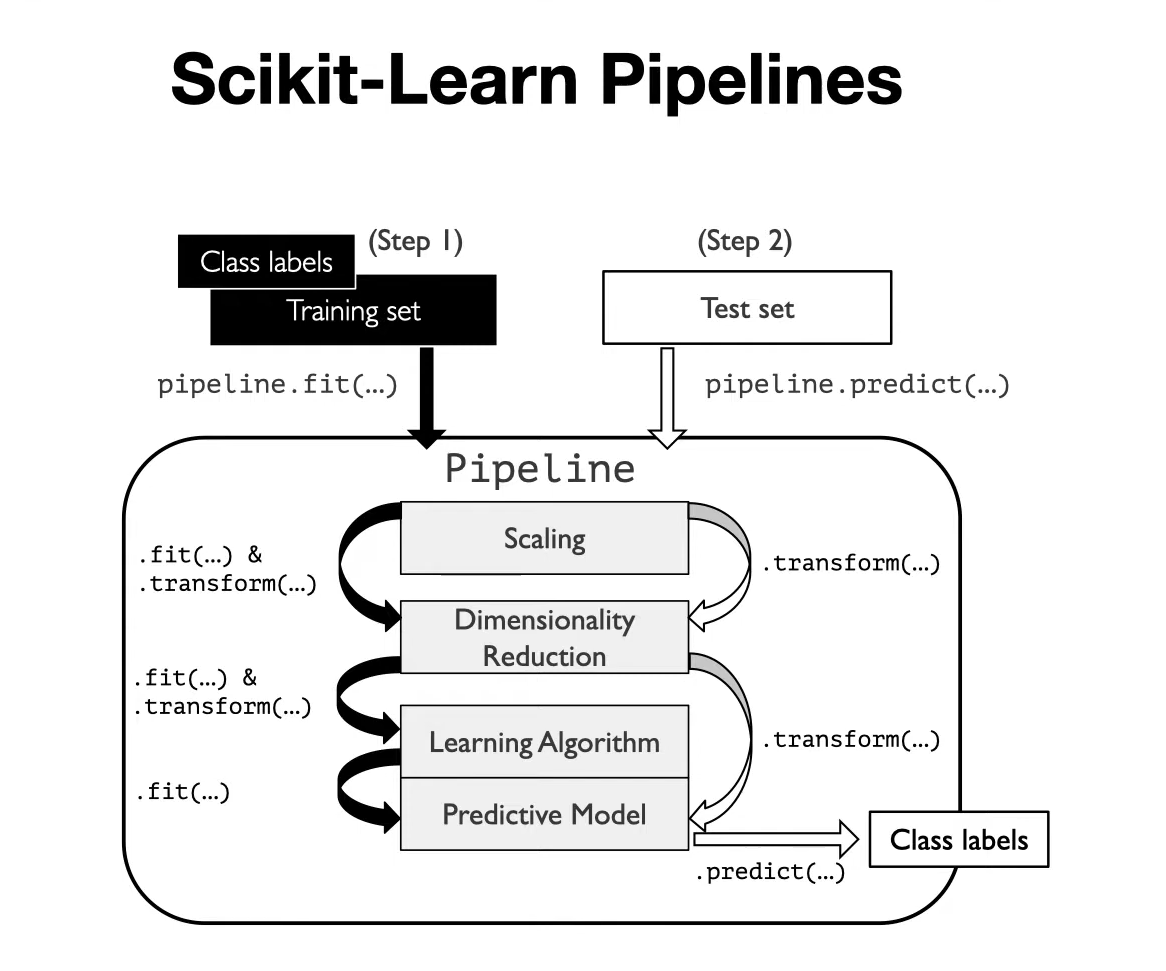

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))

In [2]:
pipe

,steps,"[('standardscaler', ...), ('kneighborsclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


It can do the following steps automatically.
- sc = StandardScaler()
- sc.fit(X_train)
- X_train_std = sc.transform(X_train)
- Knn.fit(X_train_std)

### Model Selection: Simple Holdout Method
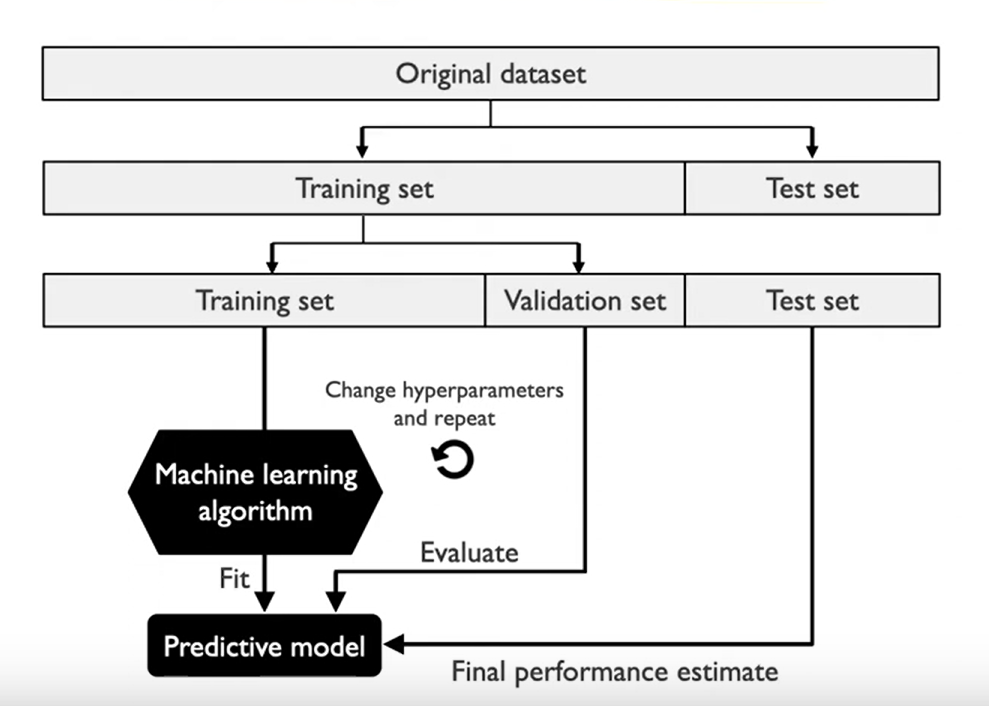

It is also called hyperparameter tuning
- We split the original dataset into training and test dataset
- Further split the training set into training and validation dataset
- We select the machine learning algorithm ex: KNN.
- We change hyperperameter for each iteration, ex: k = 3, 4, 5,..
- Based on the validation performance, we pick that model and do final performance estimate using the test set.

In [4]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
X, y = iris.data, iris.target
train_idx, valid_idx = train_test_split(np.arange(X.shape[0]), test_size=0.2, random_state=123, shuffle=True, stratify=y)

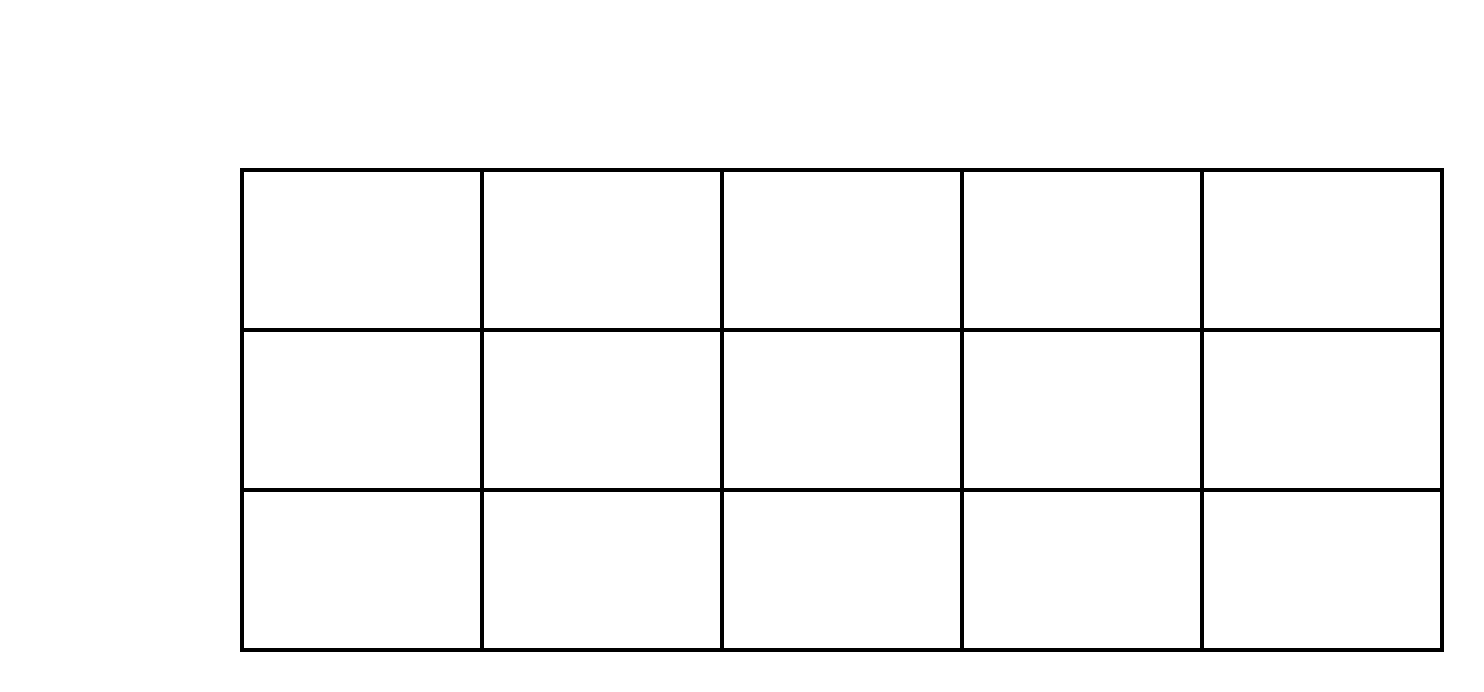
- Use all combination to get the best hyperparameter: K -> neighbours, p -> minkowski distance
- Here we have 5 x 3 -> 15 hyperparameter combinations

In [14]:
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())
param_grid = {
    'kneighborsclassifier__n_neighbors': [1, 3, 5],
    'kneighborsclassifier__p': [1, 2]
}
grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1, verbose=1)

In [15]:
X.shape[0]

150

In [16]:
grid.fit(X, y)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'kneighborsclassifier__n_neighbors': [1, 3, ...], 'kneighborsclassifier__p': [1, 2]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [17]:
print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)

# Use the best estimator for predictions
best_model = grid.best_estimator_

Best parameters: {'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__p': 2}
Best score: 0.96


In [20]:
grid.cv_results_

{'mean_fit_time': array([0.00295053, 0.00536127, 0.00641971, 0.00605559, 0.0037075 ,
        0.00267892]),
 'std_fit_time': array([0.00152567, 0.00549184, 0.00790171, 0.00451433, 0.00191526,
        0.00058021]),
 'mean_score_time': array([0.00273695, 0.0037302 , 0.00414467, 0.00409913, 0.0035749 ,
        0.00331445]),
 'std_score_time': array([0.00019696, 0.00136743, 0.00183608, 0.00185888, 0.00118954,
        0.00048356]),
 'param_kneighborsclassifier__n_neighbors': masked_array(data=[1, 1, 3, 3, 5, 5],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'param_kneighborsclassifier__p': masked_array(data=[1, 2, 1, 2, 1, 2],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'params': [{'kneighborsclassifier__n_neighbors': 1,
   'kneighborsclassifier__p': 1},
  {'kneighborsclassifier__n_neighbors': 1, 'kneighborsclassifier__p': 2},
  {'kneighborsclassifier__n_neighbors': 3, 'kneighborsclassifier__p': 1},

In [22]:
print(grid.best_score_)
print(grid.best_params_)

0.96
{'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__p': 2}


In [21]:
for i,j in zip(grid.cv_results_['params'], grid.cv_results_['mean_test_score']):
    print(f"Parameters: {i}, Mean Test Score: {j:.4f}")

Parameters: {'kneighborsclassifier__n_neighbors': 1, 'kneighborsclassifier__p': 1}, Mean Test Score: 0.9400
Parameters: {'kneighborsclassifier__n_neighbors': 1, 'kneighborsclassifier__p': 2}, Mean Test Score: 0.9467
Parameters: {'kneighborsclassifier__n_neighbors': 3, 'kneighborsclassifier__p': 1}, Mean Test Score: 0.9533
Parameters: {'kneighborsclassifier__n_neighbors': 3, 'kneighborsclassifier__p': 2}, Mean Test Score: 0.9533
Parameters: {'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__p': 1}, Mean Test Score: 0.9467
Parameters: {'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__p': 2}, Mean Test Score: 0.9600


In [19]:
import pandas as pd
results_df = pd.DataFrame(grid.cv_results_)
results_df.sort_values(by='rank_test_score', inplace=True)
results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_kneighborsclassifier__n_neighbors,param_kneighborsclassifier__p,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
5,0.002679,0.000580,0.003314,0.000484,5,2,"{'kneighborsclassifier__n_neighbors': 5, 'knei...",0.966667,0.966667,0.933333,0.933333,1.000000,0.960000,0.024944,1
3,0.006056,0.004514,0.004099,0.001859,3,2,"{'kneighborsclassifier__n_neighbors': 3, 'knei...",0.966667,0.966667,0.933333,0.900000,1.000000,0.953333,0.033993,2
2,0.006420,0.007902,0.004145,0.001836,3,1,"{'kneighborsclassifier__n_neighbors': 3, 'knei...",0.966667,0.966667,0.900000,0.933333,1.000000,0.953333,0.033993,2
4,0.003708,0.001915,0.003575,0.001190,5,1,"{'kneighborsclassifier__n_neighbors': 5, 'knei...",0.966667,0.966667,0.900000,0.900000,1.000000,0.946667,0.040000,4
1,0.005361,0.005492,0.003730,0.001367,1,2,"{'kneighborsclassifier__n_neighbors': 1, 'knei...",0.933333,0.966667,0.933333,0.900000,1.000000,0.946667,0.033993,5
0,0.002951,0.001526,0.002737,0.000197,1,1,"{'kneighborsclassifier__n_neighbors': 1, 'knei...",0.933333,0.966667,0.933333,0.900000,0.966667,0.940000,0.024944,6


RandomizedSearchCV: If we have large number of parameters, the RandomizedSearchCV goes through randomly through the parameters instead of going through all the params to save time
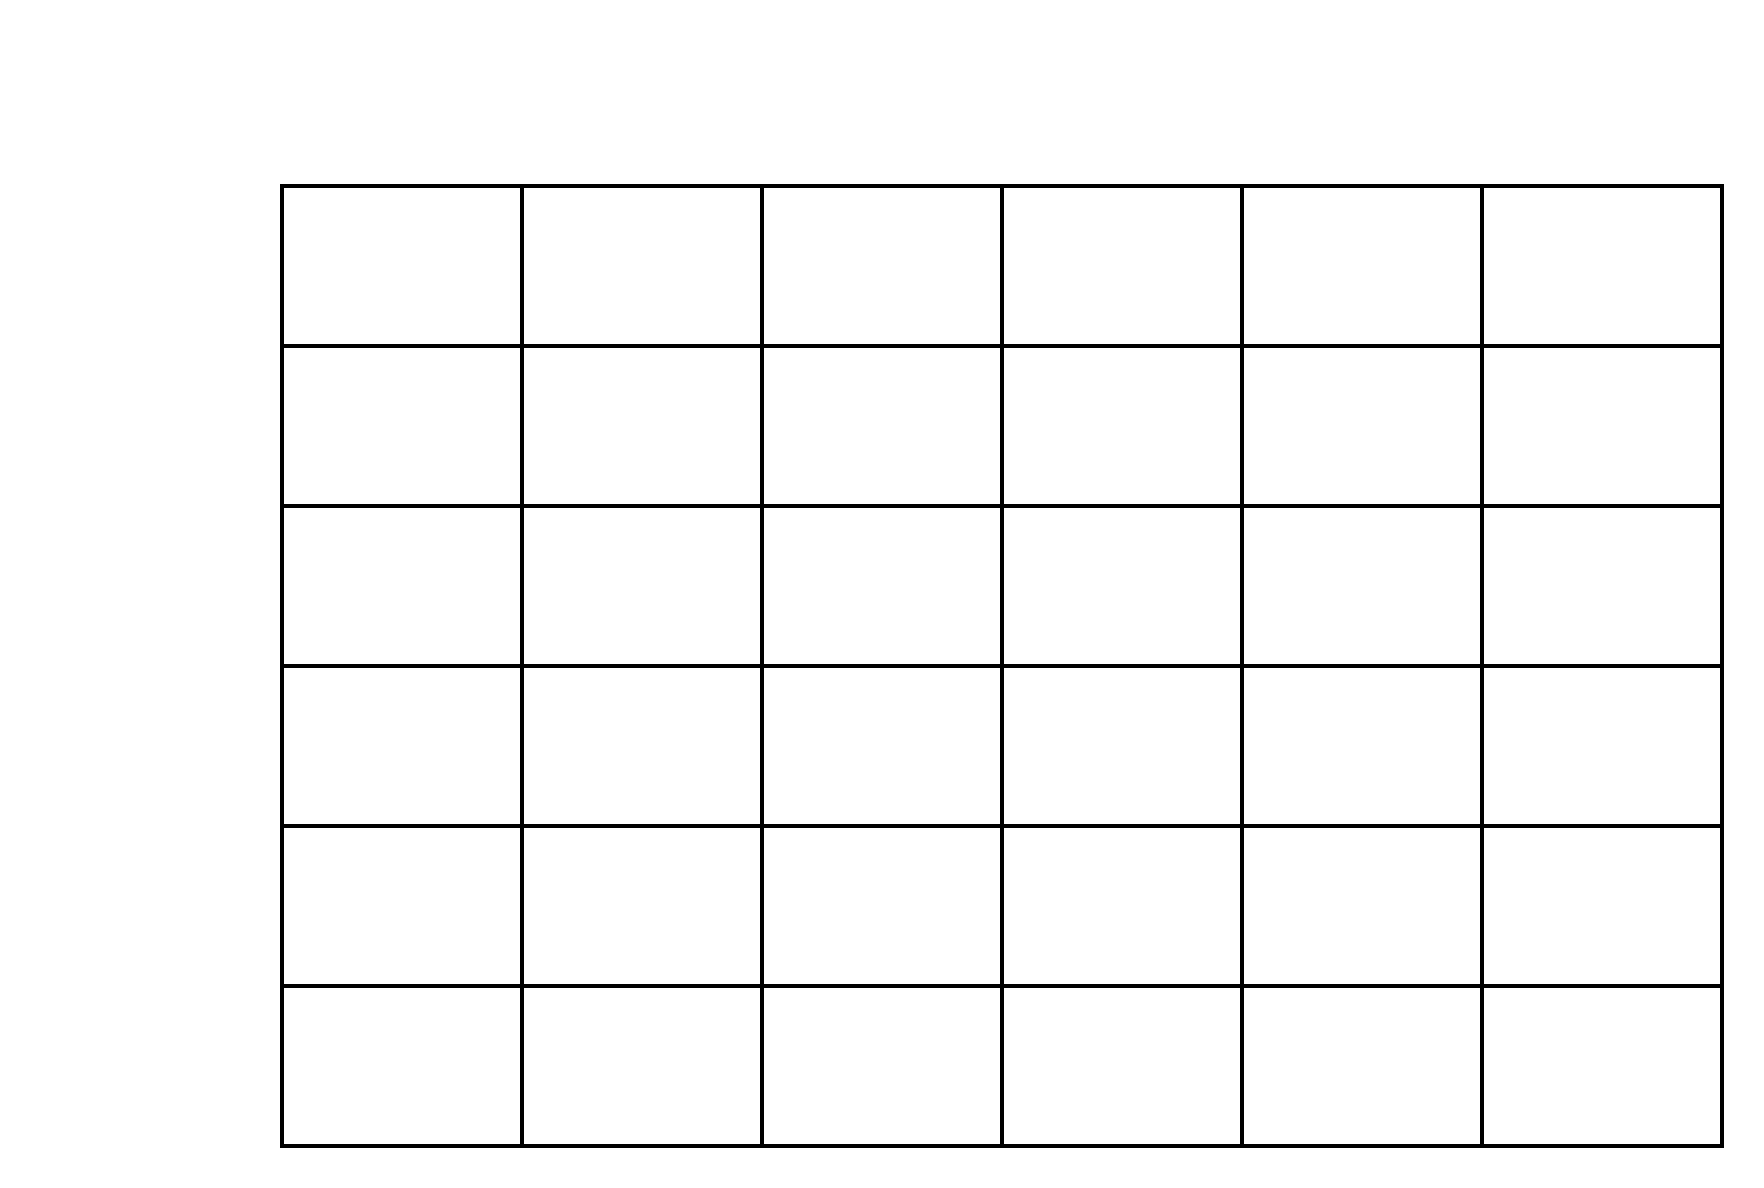
